# Step 1: Import Libraries

We start by importing all necessary Python libraries for:

- Data manipulation (`pandas`, `numpy`)
- Modeling (`scikit-learn`, `catboost`)
- Evaluation (`confusion_matrix`, `roc_auc_score`)
- Visualization (`matplotlib`, `seaborn`)

In [4]:
%pip install catboost;
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier

from sklearn.metrics import confusion_matrix, roc_auc_score

import matplotlib.pyplot as plt
import seaborn as sns

Note: you may need to restart the kernel to use updated packages.


# Step 2: Load Dataset

Load the Home Credit Default Risk dataset and preview the first few rows.  
Check the data types and missing values using `.info()`.

In [6]:
df = pd.read_csv('application_train.csv')  # adjust path if needed

df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


# Step 3: Data Cleaning & Preprocessing

- Fill missing numerical values with the median
- Fill missing categorical values with the mode
- Encode categorical variables using one-hot encoding
- Split dataset into features (`X`) and target (`y`)
- Split into training and testing sets

In [ ]:
# Fill missing numerical values
for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].median())

# Fill missing categorical values
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# One-hot encode categorical variables
df = pd.get_dummies(df, drop_first=True)

# Features and target
X = df.drop('TARGET', axis=1)
y = df['TARGET']

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Feature Scaling

Scale numerical features for Logistic Regression using `StandardScaler`.  
CatBoost does not require scaling.

In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 5: Train Models

Train two models:

1. **Logistic Regression** – requires scaled data
2. **CatBoost Classifier** – works with original features

We will predict probabilities of loan default.

In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# Dataset load
df = pd.read_csv('application_train.csv')

# Encode categorical columns
df = pd.get_dummies(df)

# Fill missing values
for col in df.columns:
    if df[col].dtype in ['float64', 'int64']:
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

# Features and target
X = df.drop('TARGET', axis=1)
y = df['TARGET']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fit Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

# Predictions
lr_pred = lr.predict(X_test_scaled)

# Output
print("Predictions (first 10):", lr_pred[:10])
print("Accuracy:", accuracy_score(y_test, lr_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, lr_pred))

Predictions (first 10): [0 0 0 0 0 0 0 0 0 0]
Accuracy: 0.9193210087312814
Confusion Matrix:
 [[56475    79]
 [ 4883    66]]


# Step 6: Define Business Cost

Set the business cost for prediction errors:

- False Negative (missed default) → $10,000
- False Positive (unnecessary loan denial) → $1,000

In [10]:
cost_fn = 10000  # missed default
cost_fp = 1000   # unnecessary denial

# Step 7: Optimize Threshold

Iterate through possible thresholds from 0 to 1:

- Compute total business cost at each threshold
- Select the threshold that minimizes total cost
- Visualize threshold vs cost

Optimal Threshold: 0.09
Minimum Business Cost: $32,535,000


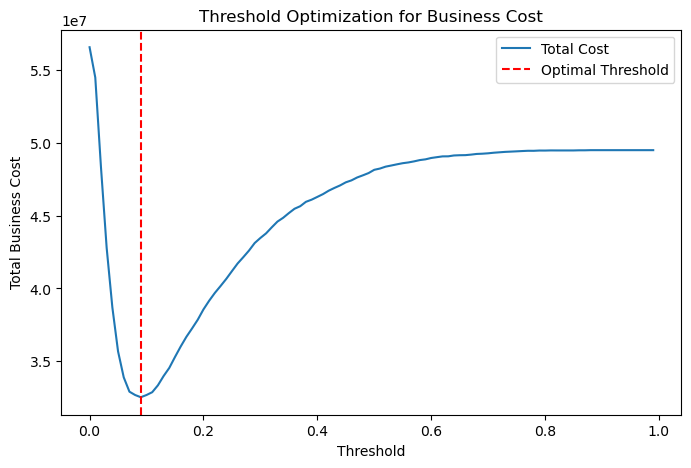

In [13]:
thresholds = np.arange(0.0, 1.0, 0.01)
costs = []

for t in thresholds:
    y_pred = (y_pred_proba_cb >= t).astype(int)  # can choose LR probabilities if preferred
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    total_cost = fn * cost_fn + fp * cost_fp
    costs.append(total_cost)

optimal_idx = np.argmin(costs)
optimal_threshold = thresholds[optimal_idx]
print(f'Optimal Threshold: {optimal_threshold:.2f}')
print(f'Minimum Business Cost: ${costs[optimal_idx]:,.0f}')

# Plot
plt.figure(figsize=(8,5))
plt.plot(thresholds, costs, label='Total Cost')
plt.axvline(optimal_threshold, color='r', linestyle='--', label='Optimal Threshold')
plt.xlabel('Threshold')
plt.ylabel('Total Business Cost')
plt.title('Threshold Optimization for Business Cost')
plt.legend()
plt.show()

# Step 8: Final Predictions

- Apply the optimal threshold to classify the test set
- Visualize the confusion matrix
- Evaluate how many defaults are correctly identified vs false positives

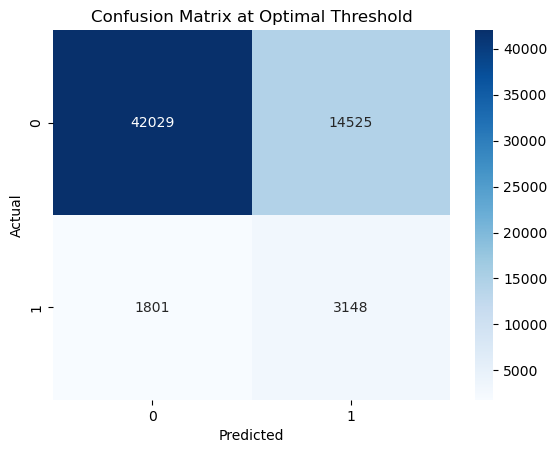

In [14]:
y_final_pred = (y_pred_proba_cb >= optimal_threshold).astype(int)

# Confusion matrix
cm = confusion_matrix(y_test, y_final_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix at Optimal Threshold')
plt.show()